# Lab 1 · Arrays, gradients, and experiment logs
**BME · MSc Deep Learning · INSTRUCTOR SOLUTIONS — do not distribute to students · 9 September 2026**

Complete T1–T5 below. The proposed total is **20 points**.
Allow about **45 minutes**, followed by **5 minutes** for submission.

Use the guided notebook and official documentation as references.
Work on your own submission and be ready to explain your code.
Follow the course rules for collaboration and AI tools; record any assistance used.

**Submit one executed `.ipynb` file to Moodle by the end of the lab.**
Do not submit only a shared Colab link. Detailed steps are at the end.

> **Instructor copy.** Keep this notebook separate from the student Moodle resources.
> It uses the same tasks, inputs, and checks as the assignment.
> The model answers illustrate acceptable reasoning; students do not need identical wording.
> Review the code to confirm use of `GradientTape`, because numerical output checks cannot prove how a gradient was obtained.

## Before you start

Open this `.ipynb` file in [Google Colab](https://colab.research.google.com/) using **Upload notebook**.
Save your own copy. Use a Python runtime; a CPU is sufficient. Run cells from top to bottom with **Shift+Enter**.

Run the setup cell below first. It records the versions actually in your session.
Use Colab's existing packages when the cell succeeds. If an import fails, ask the instructor before changing packages.
A missing-package fallback is provided in the teaching guide.

The core code was tested with TensorFlow 2.20.0 on a CPU. This is a tested version, not a claim about the newest release.
Colab's installed versions and available resources can change.

In [1]:
import sys
import re
from pathlib import Path
from datetime import datetime, timezone
from uuid import uuid4
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorboard
from IPython.display import display

np.set_printoptions(precision=4, suppress=True)
print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("TensorFlow:", tf.__version__)
print("TensorBoard:", tensorboard.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Visible GPUs:", len(tf.config.list_physical_devices("GPU")))
print("A CPU is sufficient for every exercise in this lab.")

Python: 3.12.13
NumPy: 2.5.3
TensorFlow: 2.20.0
TensorBoard: 2.20.0
Matplotlib: 3.11.1
Visible GPUs: 0
A CPU is sufficient for every exercise in this lab.


## Your details
Fill these before submission. They are not used to generate the data.

In [2]:
STUDENT_NAME = "Instructor demonstration"
NEPTUN = "DEMO00"

## How to work

Replace the `TODO` function bodies and fill the written answers.
Run the **provided check** after each task. Do not edit the checks.
A message saying **needs attention** is expected until a task is completed.

T1, T2, and T3 use separate inputs. T4 needs a working T3.
If T3 is taking time, continue with the independent tasks and ask for help.
Passing the public checks is useful feedback; it does not replace code review or the written explanations.

In [3]:
#@title Provided code — run this cell
CHECKS = {}
def check_task(name, check_function):
    try:
        check_function()
    except Exception as error:
        CHECKS[name] = False
        print(f"{name}: needs attention — {type(error).__name__}: {error}")
    else:
        CHECKS[name] = True
        print(f"{name}: public checks passed")
print("The checks give feedback. They are not an automatic final grade.")

The checks give feedback. They are not an automatic final grade.


## T1 · Build and inspect a batch — 4 points · about 8 minutes

Write `describe_batch(rows)`. Return, in this order:

1. `X`: a `float32` NumPy array.
2. `first_two`: its first two rows, keeping both axes.
3. `last_feature`: its last column as a rank-1 array.
4. `feature_means`: one mean per column.

Use array operations. Your function should also work for a different number of rows and columns.
The third column below is deliberately constant.

In [4]:
#@title Provided code — run this cell
raw_rows = [[110, 0.2, 1], [130, 0.4, 1], [150, 0.6, 1], [170, 0.8, 1]]

In [5]:
def describe_batch(rows):
    X = np.asarray(rows, dtype=np.float32)
    first_two = X[:2]
    last_feature = X[:, -1]
    feature_means = X.mean(axis=0)
    return X, first_two, last_feature, feature_means

In [6]:
#@title Provided check — run this cell
def check_t1():
    result = describe_batch(raw_rows)
    assert result is not None, "Replace the return-None scaffold in describe_batch."
    X, first_two, last_feature, feature_means = result
    assert isinstance(X, np.ndarray) and X.dtype == np.float32, "Return a float32 NumPy array."
    assert X.shape == (4, 3), "Use samples as rows and features as columns."
    np.testing.assert_allclose(X, raw_rows)
    np.testing.assert_allclose(first_two, X[:2])
    assert last_feature.shape == (4,), "Keep the last feature as a rank-1 array."
    np.testing.assert_allclose(last_feature, X[:, -1])
    assert feature_means.shape == (3,), "Return one mean per feature."
    np.testing.assert_allclose(feature_means, [140.0, 0.5, 1.0], atol=1e-6)
    # A second input checks that the function does not hard-code the first result.
    alt = describe_batch([[2, 4], [6, 8], [10, 12]])
    np.testing.assert_allclose(alt[3], [6, 8])
check_task("T1", check_t1)
if CHECKS["T1"]:
    print("Feature means:", describe_batch(raw_rows)[3])

T1: public checks passed
Feature means: [140.    0.5   1. ]


## T2 · Standardise using training statistics — 4 points · about 8 minutes

Write `standardise(train, new)` for two rank-2 arrays with matching feature columns.
Return `(train_z, new_z, mean, safe_scale)`.

- Calculate mean and standard deviation **from train only**, along `axis=0`.
- Use `keepdims=True` and the default `ddof=0`.
- Replace each standard deviation below `1e-6` by `1e-6`.
- Apply those same mean and scale arrays to both inputs.
- Return `float32` transformed arrays. Do not modify the input arrays.

The constant feature should become zero without NaN or infinity.

In [7]:
def standardise(train, new):
    train = np.asarray(train, dtype=np.float32)
    new = np.asarray(new, dtype=np.float32)
    mean = train.mean(axis=0, keepdims=True)
    safe_scale = np.maximum(train.std(axis=0, keepdims=True), np.float32(1e-6))
    train_z = (train - mean) / safe_scale
    new_z = (new - mean) / safe_scale
    return train_z, new_z, mean, safe_scale

In [8]:
#@title Provided check — run this cell
def check_t2():
    train = np.asarray(raw_rows, dtype=np.float32)
    new = np.array([[220, 1.3, 1], [80, -0.1, 1]], dtype=np.float32)
    original_train, original_new = train.copy(), new.copy()
    result = standardise(train, new)
    assert result is not None, "Replace the return-None scaffold in standardise."
    train_z, new_z, mean, scale = result
    assert mean.shape == scale.shape == (1, 3), "Keep the sample axis with length 1."
    assert train_z.shape == train.shape and new_z.shape == new.shape
    assert train_z.dtype == new_z.dtype == np.float32
    assert np.isfinite(train_z).all() and np.isfinite(new_z).all(), "Handle the constant feature."
    np.testing.assert_allclose(train_z.mean(axis=0), 0, atol=1e-6)
    np.testing.assert_allclose(train_z[:, :2].std(axis=0), 1, atol=1e-6)
    np.testing.assert_allclose(train_z[:, 2], 0, atol=1e-6)
    np.testing.assert_allclose(mean, [[140, 0.5, 1]], atol=1e-6)
    np.testing.assert_allclose(scale[0, 2], 1e-6)
    # A new sample must use the training statistics, not its own mean or scale.
    np.testing.assert_allclose(new_z, (original_new - mean) / scale, atol=1e-5)
    np.testing.assert_array_equal(train, original_train)
    np.testing.assert_array_equal(new, original_new)
check_task("T2", check_t2)
if CHECKS["T2"]:
    print("Standardised new samples:\n",
          standardise(np.asarray(raw_rows, np.float32),
                      np.array([[220, 1.3, 1]], np.float32))[1])

T2: public checks passed
Standardised new samples:
 [[3.5777 3.5777 0.    ]]


## T3 · Take one gradient step — 5 points · about 12 minutes

Write `one_step(x, y, w_initial, learning_rate)` for the model $\hat y=wx$.

1. Convert `x` and `y` to `float32` TensorFlow tensors and create a `tf.Variable` for `w`.
2. Inside `tf.GradientTape`, calculate predictions and **mean squared error**.
3. Calculate the gradient with respect to `w` and subtract `learning_rate * gradient`.
4. Return three Python floats: **loss before the update**, **gradient**, and **weight after the update**.

Use TensorFlow operations inside the tape; converting to NumPy there breaks the differentiation path.
Use automatic differentiation, rather than entering a hard-coded derivative.

In [9]:
def one_step(x, y, w_initial, learning_rate):
    x_tf = tf.convert_to_tensor(x, dtype=tf.float32)
    y_tf = tf.convert_to_tensor(y, dtype=tf.float32)
    w = tf.Variable(w_initial, dtype=tf.float32)
    with tf.GradientTape() as tape:
        predictions = w * x_tf
        loss = tf.reduce_mean(tf.square(predictions - y_tf))
    gradient = tape.gradient(loss, w)
    w.assign_sub(learning_rate * gradient)
    return float(loss.numpy()), float(gradient.numpy()), float(w.numpy())

In [10]:
#@title Provided check — run this cell
def check_t3():
    for x, y, initial, lr in [
        ([-1.0, 0.0, 1.0], [-2.5, 0.0, 2.5], 0.0, 0.1),
        ([0.5, 1.5, 2.0], [1.0, 2.0, 4.0], 0.4, 0.03),
    ]:
        result = one_step(x, y, initial, lr)
        assert result is not None, "Replace the return-None scaffold in one_step."
        loss, gradient, updated = result
        assert all(isinstance(v, float) for v in result), "Return three Python floats."
        xx, yy = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
        objective = lambda weight: np.mean((weight * xx - yy) ** 2)
        # Numerical differentiation checks the result independently of GradientTape.
        delta = 1e-4
        numerical_gradient = (objective(initial + delta) - objective(initial - delta)) / (2 * delta)
        np.testing.assert_allclose(loss, objective(initial), rtol=1e-5)
        np.testing.assert_allclose(gradient, numerical_gradient, rtol=1e-4, atol=1e-5)
        np.testing.assert_allclose(updated, initial - lr * gradient, rtol=1e-5, atol=1e-6)
        assert objective(updated) < objective(initial), "Check the update direction."
check_task("T3", check_t3)
if CHECKS["T3"]:
    print("Loss, gradient, updated weight:",
          one_step([-1, 0, 1], [-2.5, 0, 2.5], 0.0, 0.1))

T3: public checks passed
Loss, gradient, updated weight: (4.166666507720947, -3.3333334922790527, 0.3333333432674408)


## T4 · Log actual results and compare the curves — 4 points · about 10 minutes

Run the provided driver below. It uses **your T3 function** to fit `y = 2.5x`.
It compares learning rates 0.03 and 0.3, with the same data, initial weight 0, and 25 updates.

Then complete two functions:

- `log_history(history, log_dir)`: create a `tf.summary` writer, log `train_mse` at each integer step
  starting at 0, and flush and close the writer.
- `plot_histories(histories)`: return one Matplotlib Figure with both curves **in the dictionary's order**,
  a title, labelled axes, and a legend identifying the learning rates.
  Use completed-update counts 0–25 on the horizontal axis.

Do not invent or replace the loss values. The provided check reads back the event files.

In [11]:
#@title Provided code — run this cell
# Provided experiment driver: it calls YOUR one_step function.
# Step 0 = initial loss. Step 25 = loss after 25 completed updates.
ASSIGNMENT_LOG_DIR = Path("lab1_logs") / (
    "assignment-" + datetime.now(timezone.utc).strftime("%Y%m%d-%H%M%S") + "-" + uuid4().hex[:8]
)
histories = None
if CHECKS.get("T3"):
    x_experiment = np.linspace(-1, 1, 21, dtype=np.float32)
    y_experiment = np.float32(2.5) * x_experiment
    histories = {}
    for lr in [0.03, 0.3]:
        weight = 0.0
        losses = [float(np.mean((weight * x_experiment - y_experiment) ** 2))]
        for update in range(25):
            _, _, weight = one_step(x_experiment, y_experiment, weight, lr)
            losses.append(float(np.mean((weight * x_experiment - y_experiment) ** 2)))
        histories[lr] = np.asarray(losses)
    for lr, history in histories.items():
        print(f"lr={lr}: initial MSE={history[0]:.6f}; final MSE={history[-1]:.6f}")
else:
    print("Complete T3 before generating histories. T1, T2, and the conceptual questions are independent.")

lr=0.03: initial MSE=2.291667; final MSE=0.753519
lr=0.3: initial MSE=2.291667; final MSE=0.000009


In [12]:
def log_history(history, log_dir):
    writer = tf.summary.create_file_writer(str(log_dir))
    with writer.as_default():
        for step, loss in enumerate(history):
            tf.summary.scalar("train_mse", loss, step=step)
    writer.flush()
    writer.close()

def plot_histories(histories):
    fig, ax = plt.subplots(figsize=(7, 4))
    for lr, history in histories.items():
        ax.plot(np.arange(len(history)), history, label=f"learning rate = {lr}")
    ax.set(xlabel="Number of completed updates", ylabel="Training MSE",
           title="Learning-rate comparison on the same synthetic data")
    ax.legend()
    ax.grid(alpha=0.25)
    return fig

Read back 26 event values for lr=0.03; final MSE=0.753519
Read back 26 event values for lr=0.3; final MSE=0.000009
T4: public checks passed
TensorBoard logs: lab1_logs/assignment-20260907-102215-29bbcdc9


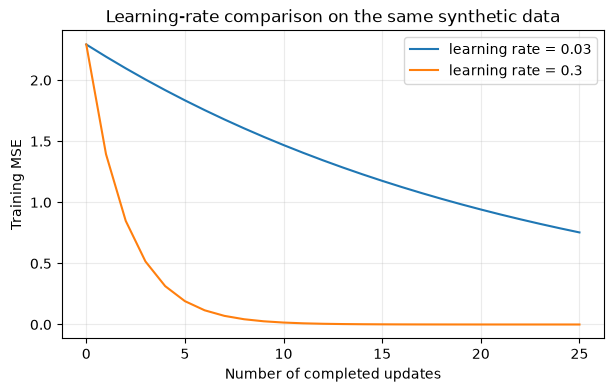

In [13]:
#@title Provided check — run this cell
# Provided readback helper: checks the event files actually written to disk.
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

logged_values = {}
assignment_figure = None
def check_t4():
    global assignment_figure, logged_values
    assert histories is not None, "Complete T3 and rerun the experiment driver first."
    # Fresh names keep a rerun from passing against old event files.
    run_group = ASSIGNMENT_LOG_DIR / uuid4().hex[:8]
    for lr, history in histories.items():
        run_dir = run_group / f"lr_{lr}"
        log_history(history, run_dir)
        assert list(run_dir.glob("events.out.tfevents.*")), "No event file was written."
        reader = EventAccumulator(str(run_dir), size_guidance={"tensors": 0})
        reader.Reload()
        assert "train_mse" in reader.Tags()["tensors"], "Use the scalar tag train_mse with tf.summary."
        events = reader.Tensors("train_mse")
        steps = [event.step for event in events]
        values = np.array([float(tf.make_ndarray(event.tensor_proto)) for event in events])
        assert steps == list(range(len(history))), "Log each step once, starting from 0."
        np.testing.assert_allclose(values, history, rtol=1e-5, atol=1e-7)
        logged_values[lr] = values
        print(f"Read back {len(values)} event values for lr={lr}; final MSE={values[-1]:.6f}")
    assignment_figure = plot_histories(histories)
    assert isinstance(assignment_figure, matplotlib.figure.Figure), "Return a Matplotlib Figure."
    ax = assignment_figure.axes[0]
    assert len(ax.lines) == 2, "Plot both learning-rate histories."
    assert ax.get_xlabel() and ax.get_ylabel() and ax.get_title() and ax.get_legend()
    for line, history in zip(ax.lines, histories.values()):
        np.testing.assert_allclose(line.get_ydata(), history, rtol=1e-5)
        np.testing.assert_allclose(line.get_xdata(), np.arange(len(history)))
check_task("T4", check_t4)
if CHECKS["T4"]:
    display(assignment_figure)
    plt.close(assignment_figure)
    print("TensorBoard logs:", ASSIGNMENT_LOG_DIR)

### Optional: inspect your runs in TensorBoard

If T4 has passed, run the cell below to inspect `train_mse`.
The **ordinary plot and printed event-file readback above** are the required saved evidence;
an embedded TensorBoard panel does not need to appear in your downloaded submission.

In [ ]:
if CHECKS.get("T4"):
    get_ipython().run_line_magic("load_ext", "tensorboard")
    get_ipython().run_line_magic("tensorboard", f"--logdir {ASSIGNMENT_LOG_DIR}")
else:
    print("Complete T4 first.")

## T5 · Interpret what you did — 3 points · about 7 minutes

Fill the strings in the next cell. Use about **2–3 sentences per answer**.

- **Q1:** Why use `axis=0` to standardise these features? Why must new data use the training mean and scale?
- **Q2:** Report the two final MSE values. Which learning rate gave the lower value after 25 updates?
  What made the comparison fair, and what does it **not** tell you about other problems?
- **Q3:** Why can this training-loss experiment not establish good performance on unseen real recordings?

If a coding task is incomplete, explain what you expected and where you got stuck rather than inventing results.

In [14]:
answers = {
    "Q1": (
        "Axis 0 combines the training samples, leaving one statistic per feature. "
        "New data must use the training mean and scale so preprocessing is consistent; "
        "fitting on validation or test inputs would use information that should be held out."
    ),
    "Q2": (
        f"The final MSE is {histories[0.03][-1]:.6f} for lr=0.03 and "
        f"{histories[0.3][-1]:.6f} for lr=0.3. "
        "The 0.3 run reaches a lower loss after 25 updates in this experiment. "
        "Both runs have the same data, initial weight, model and update count. "
        "This does not establish a universally best learning rate."
    ),
    "Q3": (
        "We measured training loss on a noiseless synthetic relationship. "
        "There is no independent held-out evaluation and no real recording variability. "
        "We would need a suitable validation/test design before claiming performance on new data."
    ),
}
assistance_used = "Instructor reference solution; official documentation listed at the end."

In [15]:
#@title Provided check — run this cell
def check_answers():
    for key in ["Q1", "Q2", "Q3"]:
        assert isinstance(answers.get(key), str) and len(answers[key].strip()) >= 30, f"Complete {key}."
    assert assistance_used.strip(), "State sources/help used, or write None."
check_task("Written answers", check_answers)
print("This check verifies that text is present. The instructor will assess its correctness.")

Written answers: public checks passed
This check verifies that text is present. The instructor will assess its correctness.


## Submit to Moodle

1. Save your notebook with your name and Neptun code filled in.
2. Restart the runtime and run all cells in order. Fix unexpected errors; read the check messages.
3. Confirm that your answers, printed results, and labelled loss plot are visible.
4. Rename the notebook to **`YOUR_NEPTUN_DL_Lab01.ipynb`**, using your own code.
5. In Colab, use **File → Download → Download .ipynb**.
6. Upload the downloaded file to the Moodle assignment and confirm the submission before the lab ends.

Submit your partial work on time if you cannot complete everything.
The instructor will assess correctness, reasoning, and clarity; the public checks are not a grade.

In [16]:
identity_ok = bool(STUDENT_NAME.strip()) and bool(re.fullmatch(r"[A-Z0-9]{6}", NEPTUN.strip().upper()))
ready = identity_ok and all(CHECKS.get(key, False) for key in ["T1", "T2", "T3", "T4", "Written answers"])
print("Name and Neptun present:", identity_ok)
print("Public checks:", CHECKS)
print("Ready for your final review:", ready)
if not ready:
    print("Review the items above. You can still submit partial work before the deadline.")
student_code = NEPTUN.strip().upper() or "YOUR_NEPTUN"
print("Required filename:", f"{student_code}_DL_Lab01.ipynb")
print("Download the executed .ipynb from Colab, then upload that file to Moodle.")
print("Open your saved submission once to check that code, answers, outputs, and the plot are included.")

Name and Neptun present: True
Public checks: {'T1': True, 'T2': True, 'T3': True, 'T4': True, 'Written answers': True}
Ready for your final review: True
Required filename: DEMO00_DL_Lab01.ipynb
Download the executed .ipynb from Colab, then upload that file to Moodle.
Open your saved submission once to check that code, answers, outputs, and the plot are included.


## Sources and attribution

Revised for the BME MSc Deep Learning lab, 9 September 2026, for Dr. Mohammed Salah Al-Radhi.
The examples and exercises here use small synthetic data.

Adapted from the 2025 **Deep learning / VITMMA19** materials at Budapest University of Technology and Economics:

- [Python and NumPy basics](https://github.com/malradhi/bme_dl_lab/blob/main/1st_week_lab/01_Python_Numpy_basics.ipynb)
- [TensorBoard basics](https://github.com/malradhi/bme_dl_lab/blob/main/1st_week_lab/02_TensorBoard_basics_TensorboardX_en.ipynb)
- [TensorFlow operations](https://github.com/malradhi/bme_dl_lab/blob/main/1st_week_lab/03_tf_basic_operations.ipynb)

Their original reuse condition is retained: any reuse or publication of any part of the notebook requires the authors' written consent.

Official references, checked 7 September 2026:

- [NumPy quickstart](https://numpy.org/doc/stable/user/quickstart.html),
  [indexing](https://numpy.org/doc/stable/user/basics.indexing.html), and
  [broadcasting](https://numpy.org/doc/stable/user/basics.broadcasting.html).
- [NumPy Generator](https://numpy.org/doc/stable/reference/random/generator.html),
  [transpose](https://numpy.org/doc/stable/reference/generated/numpy.transpose.html), and
  [NumPy 2 migration](https://numpy.org/doc/stable/numpy_2_0_migration_guide.html).
- [TensorFlow tensors](https://www.tensorflow.org/guide/tensor) and
  [automatic differentiation](https://www.tensorflow.org/guide/autodiff).
- [TensorBoard in notebooks](https://www.tensorflow.org/tensorboard/get_started),
  [summary writer](https://www.tensorflow.org/api_docs/python/tf/summary/create_file_writer), and
  [scalar summaries](https://www.tensorflow.org/api_docs/python/tf/summary/scalar).
- [Colab FAQ](https://research.google.com/colaboratory/faq.html).

## Marking notes — proposed rubric

| Task | Points | Award credit for |
|---|---:|---|
| T1 | 4 | Correct float32 conversion (1), first two rows (1), rank-1 last feature (1), per-feature means (1). |
| T2 | 4 | Training-only statistics (1), axis and retained shapes (1), constant-feature protection (1), correct transforms without mutation (1). |
| T3 | 5 | Float32 tensors and variable (1), predictions and mean squared error (1), GradientTape gradient (1), correctly signed update (1), requested returned values (1). |
| T4 | 4 | Actual scalar events with correct steps and closed writer (2), both correct curves with informative labels/title/legend (2). |
| T5 | 3 | Correct interpretation of Q1, Q2, and Q3 (1 each). |
| **Total** | **20** | Proposed lab scale; its contribution to the course grade is for the lecturer to decide. |

Give partial credit for correct parts. An error in T3 should not automatically remove all T4 credit:
inspect the student's logging/plotting code, even when its dependent run did not complete.
A runtime or TensorBoard display failure is not itself evidence of poor understanding.